<a href="https://colab.research.google.com/github/febriansyahadin/PCVK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### TUGAS PRAKTIKUM

1. Buat Gamma Correction sesuai dengan petunjuk berikut

Gamma Correction pada citra
----------------------------------
Masukkan nilai Gamma: 3


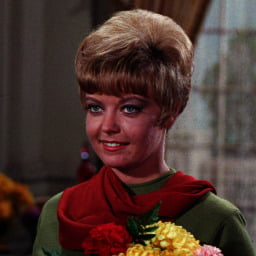

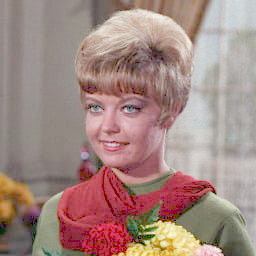

In [4]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

print('Gamma Correction pada citra')
print('----------------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    raise SystemExit

# Baca citra
img = cv2.imread('/content/drive/MyDrive/PCVK/Image/female.jpg')  # ganti sesuai nama file di Colab
if img is None:
    print('Gambar tidak ditemukan! Pastikan file sudah di-upload.')
    raise SystemExit

# Normalisasi nilai piksel ke [0,1]
normalized = img / 255.0

# Terapkan gamma correction
gamma_corrected = np.power(normalized, 1/gamma)

# Ubah kembali ke rentang 0–255
gamma_corrected = np.uint8(gamma_corrected * 255)

# Tampilkan hasil di Colab
cv2_imshow(img)
cv2_imshow(gamma_corrected)
cv2.waitKey(0)
cv2.destroyAllWindows()


2. Buat Simulasi Image Depth

Citra Asli:


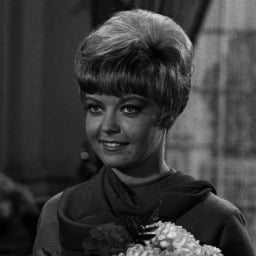

Citra Setelah Kuantisasi (2-bit):


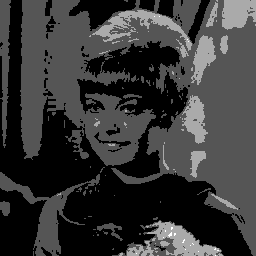

In [6]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

# Kedalaman bit yang diinginkan
bit_depth = 2   # ubah jadi 3, 4, dst untuk eksperimen

# Menghitung level berdasarkan kedalaman bit
level = 255 / (pow(2, bit_depth) - 1)

# Membaca citra grayscale
original = cv.imread('/content/drive/MyDrive/PCVK/Image/female.jpg', cv.IMREAD_GRAYSCALE)

# Membuat citra kosong dengan ukuran yang sama
depth_image = np.zeros(original.shape, original.dtype)

# Proses kuantisasi
rows, cols = original.shape
for i in range(rows):
    for j in range(cols):
        depth_image[i, j] = round(original[i, j] / level) * level

# Konversi ke tipe uint8 agar bisa ditampilkan
depth_image = np.uint8(depth_image)

# Tampilkan hasil
print("Citra Asli:")
cv2_imshow(original)
print(f"Citra Setelah Kuantisasi ({bit_depth}-bit):")
cv2_imshow(depth_image)


3. Buat modul Average Denoising

In [1]:
import cv2 as cv
import numpy as np
import os

# Baca gambar asli
img = cv.imread('/content/drive/MyDrive/PCVK/Image/galaxy.jpg')

# Folder penyimpanan
output_folder = '/content/drive/MyDrive/PCVK/Image'
os.makedirs(output_folder, exist_ok=True)

# Jumlah gambar noisy yang ingin dibuat
jumlah_gambar = 100

for i in range(jumlah_gambar):
    # Buat noise Gaussian dengan mean=0, std deviasi acak antara 10–40
    mean = 0
    sigma = np.random.randint(10, 40)
    gauss = np.random.normal(mean, sigma, img.shape).astype(np.float32)

    # Tambahkan noise ke gambar
    noisy = img.astype(np.float32) + gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    # Simpan gambar noisy ke folder
    filename = f"{output_folder}noise_{i+1}.jpg"
    cv.imwrite(filename, noisy)

print(f"{jumlah_gambar} gambar noisy berhasil dibuat di {output_folder}")


100 gambar noisy berhasil dibuat di /content/drive/MyDrive/PCVK/Image


Jumlah citra noise ditemukan: 100
PSNR untuk rata-rata 5 citra = 29.20 dB
Hasil Average 5 Citra:


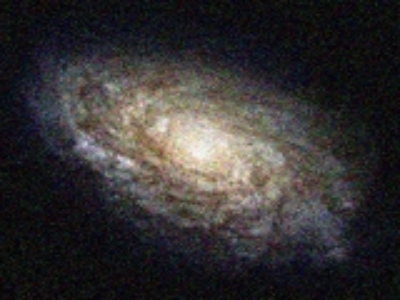

PSNR untuk rata-rata 10 citra = 29.99 dB
Hasil Average 10 Citra:


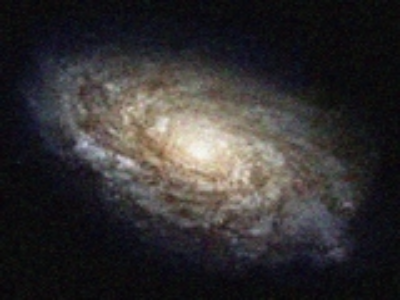

PSNR untuk rata-rata 20 citra = 31.58 dB
Hasil Average 20 Citra:


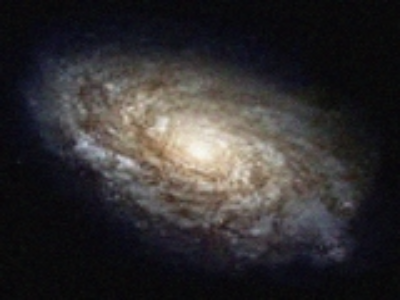

PSNR untuk rata-rata 40 citra = 32.21 dB
Hasil Average 40 Citra:


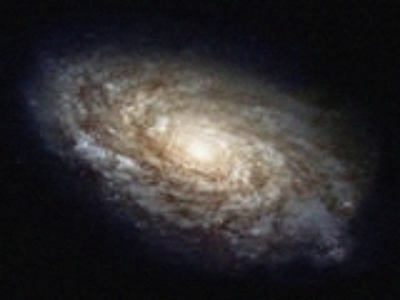

PSNR untuk rata-rata 80 citra = 32.68 dB
Hasil Average 80 Citra:


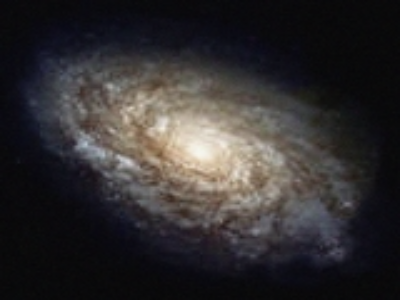

PSNR untuk rata-rata 100 citra = 32.51 dB
Hasil Average 100 Citra:


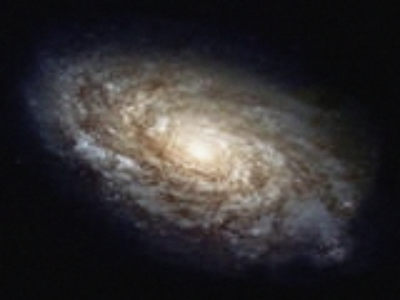

In [8]:
import cv2 as cv
import numpy as np
import glob
from math import log10, sqrt
from google.colab.patches import cv2_imshow

# --- Fungsi PSNR ---
def PSNR(img1, img2):
    if img1.shape != img2.shape or img1.dtype != img2.dtype:
        img2 = cv.cvtColor(img2, cv.COLOR_GRAY2BGR) if len(img2.shape) == 2 else img2
        img2 = img2.astype(img1.dtype) if img1.dtype != img2.dtype else img2
        if img1.shape != img2.shape:
            img2 = cv.resize(img2, (img1.shape[1], img1.shape[0]))

    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

# --- Baca citra asli ---
original = cv.imread('/content/drive/MyDrive/PCVK/Image/galaxy.jpg')

# --- Baca semua citra yang mengandung noise ---
for img_path in glob.glob('/content/drive/MyDrive/PCVK/Imagenoise_*.jpg'):
    n = cv.imread(img_path)
    if n is not None:
        cv_img.append(n)

print("Jumlah citra noise ditemukan:", len(cv_img))


# --- Daftar jumlah citra yang akan dirata-rata ---
jumlah_citra = [5, 10, 20, 40, 80, 100]

# --- Ukuran tampilan yang diinginkan ---
display_size = (400, 300)

# --- Proses average denoising ---
for jumlah in jumlah_citra:
    if len(cv_img) >= jumlah:
        images_to_average = [img for img in cv_img[:jumlah] if img.shape == original.shape]
        if not images_to_average:
            print(f"Tidak ada citra yang cocok dengan bentuk yang sesuai untuk merata-ratakan {jumlah} citra.")
            continue

        avg_img = np.mean(images_to_average, axis=0).astype(np.uint8)

        psnr_value = PSNR(original, avg_img)
        print(f"PSNR untuk rata-rata {jumlah} citra = {psnr_value:.2f} dB")

        resized_avg_img = cv.resize(avg_img, display_size)
        print(f"Hasil Average {jumlah} Citra:")
        cv2_imshow(resized_avg_img)
    else:
        print(f"Tidak cukup citra ({len(cv_img)} ditemukan) dengan bentuk yang sesuai untuk merata-ratakan {jumlah} citra.")


4. Buat image masking

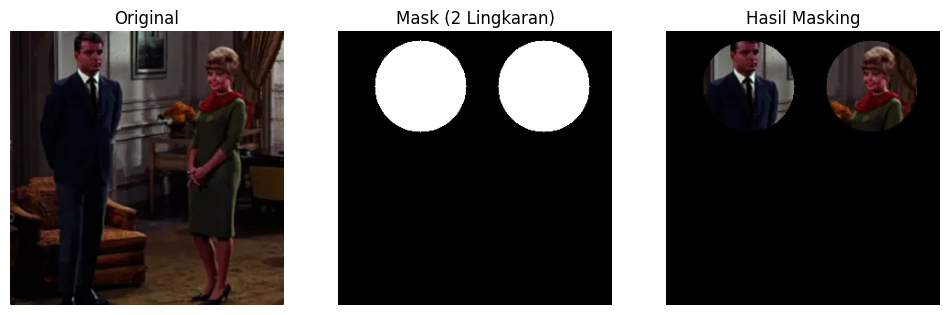

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Image/couple.webp')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask kosong
mask = np.zeros(img.shape[:2], dtype="uint8")

# Ukuran gambar
h, w = img.shape[:2]

# Buat 2 lingkaran dengan posisi berbeda
y_pos = int(h*0.5) - 90 #untuk mengatur lingkaran agar lebih keatas
cv.circle(mask, (int(w*0.30), y_pos), 50, 255, -1)   # lingkaran kiri
cv.circle(mask, (int(w*0.75), y_pos), 50, 255, -1)   # lingkaran kanan

# Masking gabungan
masked = cv.bitwise_and(img, img, mask=mask)

# Tampilkan hasil
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask (2 Lingkaran)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(masked); plt.title("Hasil Masking"); plt.axis("off")
plt.show()

5. Menggunakan operator lain

NOT(komplemen)

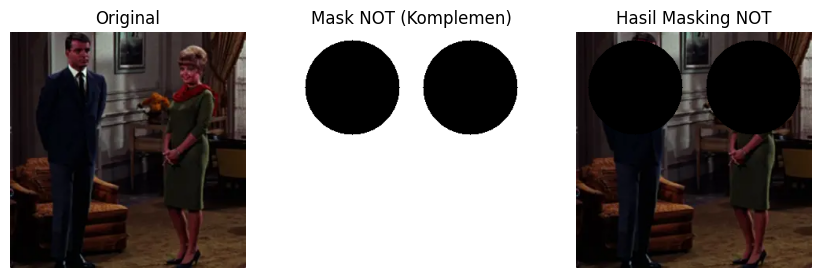

In [12]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Image/couple.webp')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# Buat komplemen mask (NOT)
mask_not = cv.bitwise_not(mask)

# Terapkan mask dan komplemen mask

masked_not = cv.bitwise_and(img, img, mask=mask_not)

# Tampilkan hasil
plt.figure(figsize=(14,5))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_not, cmap="gray"); plt.title("Mask NOT (Komplemen)"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(masked_not); plt.title("Hasil Masking NOT"); plt.axis("off")
plt.show()

OR (Atau)

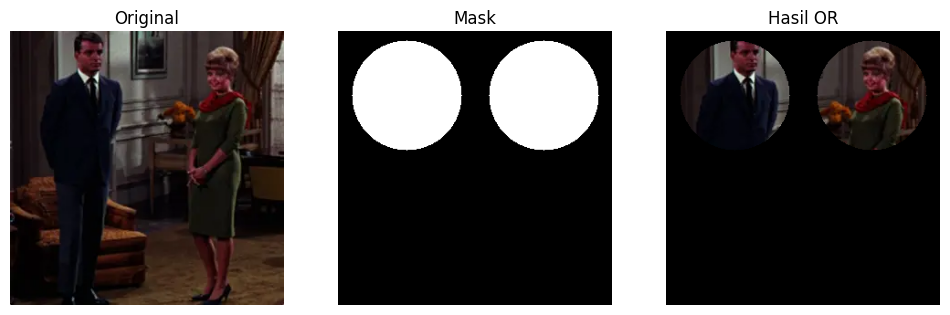

In [14]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Image/couple.webp')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# OR
or_result = cv.bitwise_or(img, img, mask=mask)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(or_result); plt.title("Hasil OR"); plt.axis("off")
plt.show()



AND (Dan)

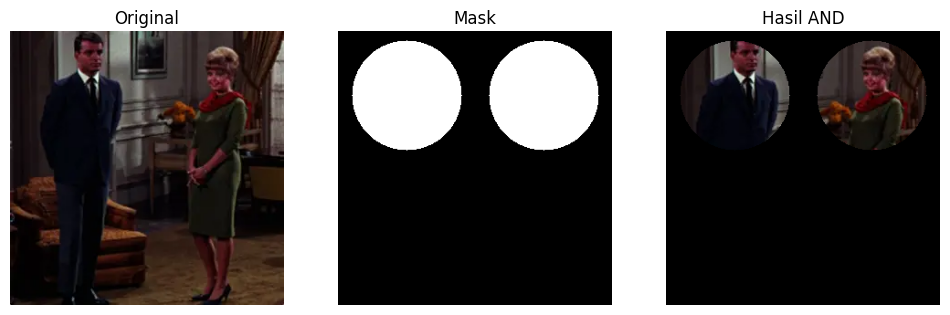

In [15]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Image/couple.webp')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# AND
and_result = cv.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(and_result); plt.title("Hasil AND"); plt.axis("off")
plt.show()

NAND (Not And)

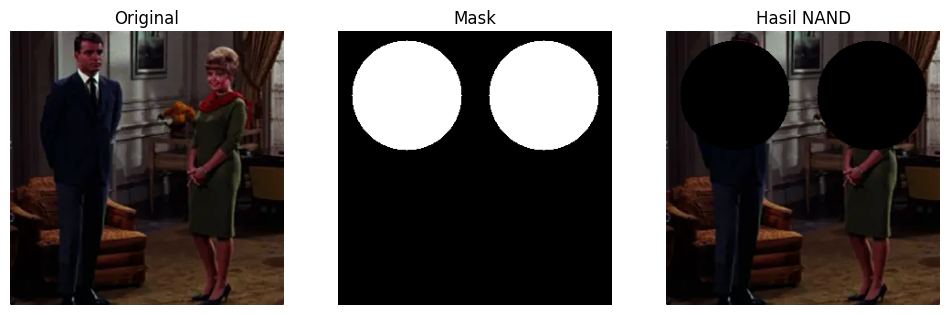

In [16]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Image/couple.webp')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# NAND = NOT(AND)
nand_result = cv.bitwise_and(img, img, mask=cv.bitwise_not(mask))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(nand_result); plt.title("Hasil NAND"); plt.axis("off")
plt.show()

XOR (Exlusive Or)

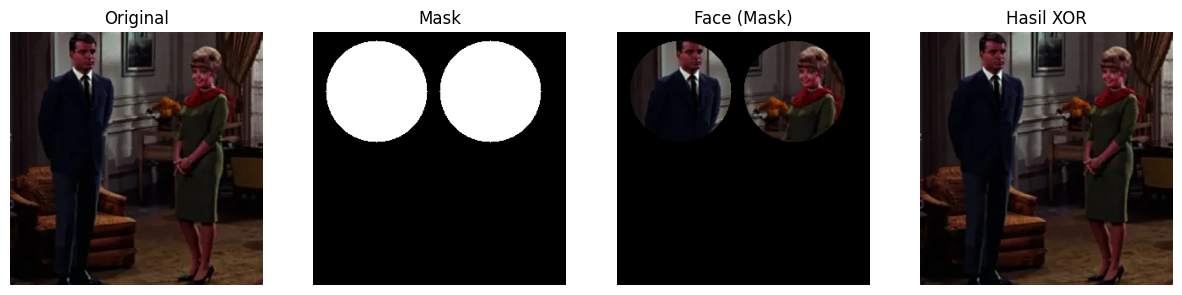

In [17]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Image/couple.webp')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran (area wajah)
mask = np.zeros(img.shape[:2], dtype="uint8")
h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.70), y_pos), 60, 255, -1)

# Buat inverse mask
mask_inv = cv.bitwise_not(mask)

# Pisahkan area wajah dan background
face = cv.bitwise_and(img, img, mask=mask)        # hanya wajah
background = cv.bitwise_and(img, img, mask=mask_inv)  # hanya background

# XOR wajah dengan background
xor_result = cv.bitwise_xor(face, background)

# Tampilkan hasil
plt.figure(figsize=(15,5))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(face); plt.title("Face (Mask)"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(xor_result); plt.title("Hasil XOR"); plt.axis("off")
plt.show()


Tuliskan hasil analisa anda: Gamma correction berfungsi untuk mengatur tingkat kecerahan citra, di mana nilai gamma kecil membuat citra lebih terang sedangkan nilai gamma besar membuat citra lebih gelap. Bit depth berhubungan dengan jumlah level intensitas warna; semakin rendah bit depth maka citra terlihat kasar karena gradasinya terbatas, sedangkan bit depth tinggi menghasilkan citra dengan gradasi lebih halus. PSNR digunakan untuk mengukur kualitas citra hasil pemrosesan dibanding citra asli, semakin tinggi nilai PSNR maka kualitas citra semakin baik. Pada average denoising, dengan menambahkan dan merata-ratakan banyak citra noisy, noise acak dapat dikurangi sehingga kualitas citra meningkat dan nilai PSNR lebih tinggi. Sementara itu, image masking dengan operasi logika (AND, OR, NOT, XOR) memungkinkan kita untuk memanipulasi atau mengekstrak bagian tertentu dari citra sesuai kebutuhan, misalnya untuk segmentasi atau penggabungan objek.